In [66]:
# Import packages
import os
import numpy as np
from sklearn.model_selection import KFold, train_test_split
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import scipy as sc
import seaborn as sns

In [67]:
DATA_DIR = "../data/"
ALPHABET_FILE = os.path.join(DATA_DIR, "Matrices/alphabet")
BACKGROUND_FILE = os.path.join(DATA_DIR, "Matrices/bg.freq.fmt")
BLOSUM_FILE = os.path.join(DATA_DIR, "Matrices/blosum62.freq_rownorm")

### Helper functions

In [68]:
# Generate alphabet for usage
def generate_alphabet():
    alphabet = np.loadtxt(ALPHABET_FILE, dtype=str)
    return alphabet

In [69]:
# Load background frequencies
def background_frequencies(alphabet):
    background_frequencies = np.loadtxt(BACKGROUND_FILE, dtype=float)
    
    background = list()
    for i in range(0, 20):
        background.append(background_frequencies[i])

    return background

In [70]:
# Read peptide file
def load_peptide_data(file_name):

    peptide_file = os.path.join(DATA_DIR, file_name)
    loaded_peptides = np.loadtxt(peptide_file, dtype=str)

    peptides = []

    for line in loaded_peptides:

        peptides.append(line.upper())

    return peptides

In [71]:
# Convert peptide to collection of numbers
def encode(sequence, alphabet):

    enc = [0] * len(sequence)
    convert_noncanonical_a = {
        "U": "C"
    }

    updated_sequence = sequence[:]

    for idx, a in enumerate(sequence):
        if a in convert_noncanonical_a:
            #print(f"Sequence contained non-canonical amino acid {a}. Now converted to {convert_noncanonical_a[a]}")
            a = convert_noncanonical_a[a]
            updated_sequence = sequence[:idx] + a + sequence[idx+1:]

        a_symbol = alphabet.index(a)
        enc[idx] = a_symbol

    return enc, updated_sequence

In [72]:
# Load Blosum
def blosum_to_emission_propabilities(blosum_file, ref_aa, alphabet):
    ref_aa_index = alphabet.index(ref_aa)
    with open(blosum_file, "r") as f:
        for i,line in enumerate(f):
            if i == ref_aa_index:
                #return line
                return list(map(float, line.strip().split(" ")))


### Model

**Investigating biological states**

- State 1 - positively charged regions, N-region
- State 2 - hydrophobic regions, H-region
- State 3 - cleavage site, C-region

In [73]:
class BaumWelch:
    """
    Initialize θ0

    Repeat:
        E-step:
            compute gamma, xi using θk

        M-step:
            compute θk+1 from gamma, xi

        replace θk with θk+1
    """

    def __init__(self, peptides, states, initial_probability, transition_matrix, emission_probability, alphabet):
        
        self.peptides = peptides
        self.states = states
        self.initial_probability = initial_probability
        self.transition_matrix = transition_matrix
        self.emission_probability = emission_probability
        self.alphabet = alphabet

    ###################################################################################################################
    def alpha_initialize(self, peptide):

        # Initialize
        alpha = np.zeros(shape=(self.states, len(peptide)))

        for i in range(self.states):
            alpha[i][0] = self.initial_probability[i] \
                            * self.emission_probability[i][peptide[0]]

        return alpha

    ###################################################################################################################
    def beta_initialize(self, peptide):

        # Initialize
        beta = np.zeros(shape=(self.states, len(peptide)))

        # Defining beta[T] (final position) as 1
        for i in range(self.states):
            beta[i][-1] = 1

        return beta

    ###################################################################################################################
    def forward_probability(self, peptide, alpha):
    
        # print("emission_probability", emission_probability)
        # print("transition_matrix", transition_matrix)

        T = len(peptide)

        c = np.zeros(T)     # Scaling factor
        c[0] = np.sum(alpha[:,0])

        if c[0] == 0:
            c[0] = 1e-300

        alpha[:,0] /= c[0]  # Scale alpha

        for t in range(1, T):

            for i in range(self.states):
                _sum = 0
                for j in range(self.states):

                    _sum +=  alpha[j][t-1] \
                                * self.transition_matrix[j][i]
                
                # Emission is applied AFTER summing over previous states
                alpha[i][t] = _sum * self.emission_probability[i][peptide[t]]

            c[t] = np.sum(alpha[:, t])  # Sum across all states
            if c[t] == 0:
                c[t] = 1e-300
            
            alpha[:, t] /= c[t]     # Scale all of alpha

        return alpha, c
    
    ###################################################################################################################
    def backward_probability(self, peptide, beta, c):

        T = len(peptide)

        beta[:, -1] /= c[-1]    # Scale final column (1) of beta

        for t in range(T - 2, -1, -1):

            for i in range(self.states):
                _sum = 0
                for j in range(0, self.states):
                    _sum += self.emission_probability[j][peptide[t+1]] \
                                * self.transition_matrix[i][j] \
                                    * beta[j][t+1] 
                
                beta[i][t] = _sum
            
            beta[:, t] /= c[t]  # Scale all of beta

        return beta
    
    ###################################################################################################################
    def calculate_gamma(self, alpha, beta):

        numerator = alpha * beta
        denominator = numerator.sum(axis=0)

        gamma = numerator / denominator

        return gamma
    
    ###################################################################################################################
    def calculate_xi(self, peptide, alpha, beta):

        T = len(peptide)
        xi = np.zeros((self.states, self.states, T-1))

        for t in range(T-1):

            denominator = 0
            for i in range(self.states):
                for j in range(self.states):

                    denominator += alpha[i][t] \
                                    * beta[j][t+1] \
                                        * self.transition_matrix[i][j] \
                                            * self.emission_probability[j][peptide[t+1]]
                    
            for i in range(self.states):
                for j in range(self.states):   
                    numerator = alpha[i][t] \
                                * beta[j][t+1] \
                                    * self.transition_matrix[i][j] \
                                        * self.emission_probability[j][peptide[t+1]]     

                    xi[i, j, t] = numerator / denominator
                    # Numerator value updates with each iteration
                    # Denominator value stays the same

        return xi
    
    ###################################################################################################################
    def update_parameters(self, all_input_encodes, gamma_list, xi_list):
    
        R = len(all_input_encodes)

        final_probability = np.zeros(self.states)

        final_transition_matrix_num = np.zeros((self.states, self.states))
        final_transition_matrix_den = np.zeros(self.states)

        final_emission_probability_num = np.zeros((self.states, len(self.alphabet)))
        final_emission_probability_den = np.zeros(self.states)

        for i, r in enumerate(all_input_encodes):
            
            gamma = gamma_list[i]
            xi = xi_list[i]
            T = gamma.shape[1]

            # Initial state distribution
            final_probability += gamma[:, 0]

            # Transition matrix
            final_transition_matrix_den += np.sum(gamma[:, :T-1], axis=1)
            final_transition_matrix_num += np.sum(xi, axis=2)

            # Iterate over all the "positions" in sequence
            for t in range(T):
                seq_idx = r[t]
                a = self.alphabet[seq_idx]

                # Iterate over eveyr state
                for j in range(self.states):
                    final_emission_probability_num[j, seq_idx] += gamma[j, t]
            
            final_emission_probability_den += np.sum(gamma, axis=1)

        final_probability /= R 
        final_transition_matrix = final_transition_matrix_num / final_transition_matrix_den[:, None]
        final_emission_probability = final_emission_probability_num / final_emission_probability_den[:, None]

        return final_probability, final_transition_matrix, final_emission_probability
    
    ###################################################################################################################
    def run(self):
        peptide_nr = 0

        all_input_encodes = []
        gamma_list = []
        xi_list = []

        for peptide in self.peptides:

            peptide_nr += 1

            # Convert sequence from amino acids to numbers
            input_encode, peptide = encode(peptide, self.alphabet)
            all_input_encodes.append(input_encode)
            
            # Initialize
            alpha = self.alpha_initialize(input_encode)
            beta = self.beta_initialize(input_encode)
            
            # Calculate probabilities
            alpha, c = self.forward_probability(input_encode, alpha)
            beta = self.backward_probability(input_encode, beta, c)   

            # Expected state
            # Probability of being in state i at time t given the observed sequence Y
            gamma = self.calculate_gamma(alpha, beta)

            # Expected transition
            # Probability of being in state i and j at times t and t+1 respectively given the observed sequence Y
            xi = self.calculate_xi(input_encode, alpha, beta)

            # Store
            gamma_list.append(gamma)
            xi_list.append(xi)

        final_probability, final_transition_matrix, final_emission_probability = self.update_parameters(all_input_encodes, gamma_list, xi_list)

        # Update model
        self.initial_probability = final_probability
        self.transition_matrix = final_transition_matrix
        self.emission_probability = final_emission_probability

        return final_probability, final_transition_matrix, final_emission_probability, all_input_encodes

In [74]:
###################################################################################################################
def forward_initialize(input_encode, states, initial_probability, emission_probability):

    alpha = np.zeros(shape=(states, len(input_encode)))

    for i in range(states):
        alpha[i][0] = initial_probability[i] * emission_probability[i][input_encode[0]]

    return alpha

###################################################################################################################
def forward(input_encode, states, alpha, transition_matrix, emission_probability):
    """
    Summed probability over all paths giving rise to a given sequence
    """

    for i in range(1, len(input_encode)):

        for j in range(states):
            _sum = 0
            for k in range(states):
                _sum += emission_probability[j][input_encode[i]] * alpha[k][i-1] * transition_matrix[k][j]

            alpha[j][i] = _sum

    return alpha

###################################################################################################################
def log_likelihood(alpha):
    return np.log(np.sum(alpha[:, -1]))

In [75]:
def classify_sequence(input_encode, mito_model, cyto_model, states):

    # Define initial probability, transition matrix, and emission probability
    mito_probability, mito_transition_matrix, mito_emission_probability = mito_model
    cyto_probability, cyto_transition_matrix, cyto_emission_probability = cyto_model

    # Run forward algorithm for mito
    mito_alpha = forward_initialize(input_encode, states, mito_probability, mito_emission_probability)
    mito_alpha = forward(input_encode, states, mito_alpha, mito_transition_matrix, mito_emission_probability)
    mito_ll = log_likelihood(mito_alpha)

    # Run forward algorithm for cyto
    cyto_alpha = forward_initialize(input_encode, states, cyto_probability, cyto_emission_probability)
    cyto_alpha = forward(input_encode, states, cyto_alpha, cyto_transition_matrix, cyto_emission_probability)
    cyto_ll = log_likelihood(cyto_alpha)

    # Calculate log-likelihood ratio
    llr = mito_ll - cyto_ll

    return llr

def classify_sequence_prop(input_encode, mito_model, cyto_model, states):

    # Define initial probability, transition matrix, and emission probability
    mito_probability, mito_transition_matrix, mito_emission_probability = mito_model
    cyto_probability, cyto_transition_matrix, cyto_emission_probability = cyto_model

    # Run forward algorithm for mito
    mito_alpha = forward_initialize(input_encode, states, mito_probability, mito_emission_probability)
    mito_alpha = forward(input_encode, states, mito_alpha, mito_transition_matrix, mito_emission_probability)
    #mito_ll = log_likelihood(mito_alpha)
    mito_likelihood = np.sum(mito_alpha[:, -1])

    # Run forward algorithm for cyto
    cyto_alpha = forward_initialize(input_encode, states, cyto_probability, cyto_emission_probability)
    cyto_alpha = forward(input_encode, states, cyto_alpha, cyto_transition_matrix, cyto_emission_probability)
    #cyto_ll = log_likelihood(cyto_alpha)
    cyto_likelihood = np.sum(cyto_alpha[:, -1])

    # Calculate log-likelihood ratio
    #llr = mito_ll - cyto_ll

    #calculate normalized likelhoods (propability for mito)
    prop = mito_likelihood / (mito_likelihood + cyto_likelihood)

    return prop

In [76]:
def evaluate_models(test_data, mito_models, cyto_models, alphabet, n_iterations):

    accuracies = []
    llrs = []

    for iteration in range(n_iterations):
        mito_model = mito_models[iteration]
        cyto_model = cyto_models[iteration]

        correct = 0
        total = len(test_data)

        iteration_llrs = []

        for peptide, label in test_data:
            
            # Convert sequence from amino acids to numbers
            input_encode, peptide = encode(peptide, alphabet)

            # Classify test sequence
            llr = classify_sequence(input_encode, mito_model, cyto_model, states)
            iteration_llrs.append(llr)
            
            pred = 1 if llr > 0 else 0   # 1 = mito, 0 = cyto
            if pred == label:
                correct += 1

        llrs.append(iteration_llrs)
        accuracies.append(correct / total)

    return accuracies, llrs

def predict(peptide, mito_model, cyto_model, alphabet, states):
    # Convert sequence from amino acids to numbers
    input_encode, peptide = encode(peptide, alphabet)
    # Classify test sequence
    llr = classify_sequence(input_encode, mito_model, cyto_model, states)
    pred = 1 if llr > 0 else 0   # 1 = mito, 0 = cyto
    return llr, pred

def predict_prop(peptide, mito_model, cyto_model, alphabet, states):
    # Convert sequence from amino acids to numbers
    input_encode, peptide = encode(peptide, alphabet)
    # Classify test sequence
    prop = classify_sequence_prop(input_encode, mito_model, cyto_model, states)
    #pred = 1 if llr > 0 else 0   # 1 = mito, 0 = cyto
    return prop


#def evaluate_model(eval_data, mito_model, cyto_model, alphabet, states):
#    predicted = [predict(peptide, mito_model, cyto_model, alphabet, states)[1] for peptide, lbl in eval_data]
#    predicted = np.asarray(predicted, dtype=np.int64)
#    target = np.asarray(eval_data[:, 1], dtype=np.int64)
#    acc = accuracy(target, predicted)
#    mcc_score= mcc(target.ravel(), predicted.ravel())
#
#    return acc, mcc_score

def evaluate_model(eval_data, mito_model, cyto_model, alphabet, states):
    llrs = [predict(peptide, mito_model, cyto_model, alphabet, states)[0] for peptide, lbl in eval_data]
    predicted = [predict(peptide, mito_model, cyto_model, alphabet, states)[1] for peptide, lbl in eval_data]
    predicted = np.asarray(predicted, dtype=np.int64)
    target = np.asarray(eval_data[:, 1], dtype=np.int64)
    acc = accuracy(target, predicted)
    mcc_score= mcc(target.ravel(), predicted.ravel())
    auc_score = auc(target, llrs)

    return acc, mcc_score, auc_score

def evaluate_model_prop(eval_data, mito_model, cyto_model, alphabet, states):
    predicted = [predict_prop(peptide, mito_model, cyto_model, alphabet, states) for peptide, lbl in eval_data]
    #predicted = np.asarray(predicted, dtype=np.int64)
    target = np.asarray(eval_data[:, 1], dtype=np.int64)
    binary_prediction = [1 if p > 0.5 else 0 for p in predicted]
    acc = accuracy(target, binary_prediction)
    mcc_score= mcc(target.ravel(), binary_prediction)
    auc_score = auc(target, predicted)

    return acc, mcc_score, auc_score

def accuracy(target, predicted):
    return metrics.accuracy_score(target, predicted)

def mcc(target, predicted):
    mcc_score = metrics.matthews_corrcoef(target, predicted)
    return mcc_score

def auc(target, predicted_prop):
    fpr, tpr, thresholds = metrics.roc_curve(target, predicted_prop)
    return metrics.auc(fpr, tpr)

def plot_confusion_matrix(targets, predicted):

    cm = metrics.confusion_matrix(targets, predicted)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.4)

    sns.heatmap(
        cm_norm,
        annot=True,
        cmap="Blues",
        linewidths=0.5,
        fmt=".2f",
        annot_kws={"size": 12}
    )

    plt.xticks([0.5, 1.5], ["Mitochondria", "Cytosol"], rotation=0, size=12)
    plt.yticks([0.5, 1.5], ["Mitochondria", "Cytosol"], rotation=0, size=12)

    plt.xlabel("Predicted label", size=14)
    plt.ylabel("True label", size=14)
    plt.title("Confusion Matrix", size=14)

    plt.savefig(os.path.join(DATA_DIR, "confusion_matrix.png"), bbox_inches='tight', transparent=True)
    plt.show()

    return

In [ ]:
def cross_validation(outer_data, n_iterations):

    initial_probability = [1.0/states, 1.0/states, 1.0/states, 1/ states]
    transition_matrix = np.asarray([
                                [0.80, 0.15, 0.00, 0.05],   # N‑region ('+' charged) is short
                                [0.00, 0.85, 0.10, 0.05],   # H‑region is long
                                [0.00, 0.0, 0.95, 0.05],
                                [0,0,0,1]   # C‑region has almost no transitions out
                            ])

    #n_region = np.array([0.05, 0.12, 0.04, 0.02, 0.03,   # A, R, N, D, C
    #                    0.04, 0.02, 0.05, 0.03, 0.03,   # Q, E, G, H, I
    #                    0.03, 0.12, 0.03, 0.03, 0.04,   # L, K, M, F, P
    #                    0.06, 0.06, 0.02, 0.03, 0.03    # S, T, W, Y, V
    #                    ])
    #h_region = np.array([0.03, 0.01, 0.01, 0.01, 0.02,   # A, R, N, D, C
    #                    0.02, 0.01, 0.02, 0.01, 0.12,   # Q, E, G, H, I
    #                    0.18, 0.01, 0.06, 0.10, 0.03,   # L, K, M, F, P
    #                    0.03, 0.03, 0.08, 0.03, 0.20    # S, T, W, Y, V
    #                    ])
    #c_region = np.array([0.10, 0.03, 0.04, 0.03, 0.03,   # A, R, N, D, C
    ##                    0.04, 0.03, 0.08, 0.03, 0.04,   # Q, E, G, H, I
    #                   0.04, 0.03, 0.03, 0.03, 0.04,   # L, K, M, F, P
    #                    0.12, 0.10, 0.02, 0.03, 0.03    # S, T, W, Y, V
    #                    ])

    n_region = blosum_to_emission_propabilities(BLOSUM_FILE, "K", alphabet)
    h_region = blosum_to_emission_propabilities(BLOSUM_FILE, "L", alphabet)
    c_region = blosum_to_emission_propabilities(BLOSUM_FILE, "A", alphabet)
    b_state = background_frequencies(alphabet)



    emission_probability = [n_region, h_region, c_region,b_state]

    # NOTE: to obtain 20/20/60 ratio of the original data, split has to be 0.25.
    # Split 40% into 20% test and 20% evaluate
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    all_accuracies = []
    all_mccs = []
    all_auc = []

    best_mito_models = []
    best_cyto_models = []
    for train_idx, test_idx in kf.split(outer_data):

        train_data = outer_data[train_idx]
        test_data = outer_data[test_idx]

        mito_train = [peptide for peptide, label in train_data if label == 1]
        cyto_train = [peptide for peptide, label in train_data if label == 0]

        # Initialize Baum Welch
        mito_baum = BaumWelch(mito_train, states,
                              initial_probability.copy(),
                              transition_matrix.copy(),
                              emission_probability.copy(),
                              alphabet)

        cyto_baum = BaumWelch(cyto_train, states,
                              initial_probability.copy(),
                              transition_matrix.copy(),
                              emission_probability.copy(),
                              alphabet)

        best_mito_model, best_cyto_model = None, None
        best_accuracy, best_auc = 0, 0
        accuracies, mcc_scores, auc_scores  = [], [], []
        for iteration in range(n_iterations):
            # TRAIN
            # Mito HMM and store mito model performance
            mito_probability, mito_transition_matrix, mito_emission_probability, mito_all_input_encodes = mito_baum.run()
            mito_model = (mito_probability, mito_transition_matrix, mito_emission_probability)

            # Cyto HMM and store cyto model performance
            cyto_probability, cyto_transition_matrix, cyto_emission_probability, cyto_all_input_encodes = cyto_baum.run()
            cyto_model = (cyto_probability, cyto_transition_matrix, cyto_emission_probability)

            # EVALUATE
            accuracy, mcc_score, auc = evaluate_model(test_data, mito_model, cyto_model, alphabet, states)
            #accuracy, mcc_score, auc = evaluate_model_prop(test_data, mito_model, cyto_model, alphabet, states)
            if auc > best_auc:
                best_accuracy = accuracy
                best_auc = auc
                best_cyto_model = cyto_model
                best_mito_model = mito_model
            accuracies.append(accuracy)
            mcc_scores.append(mcc_score)
            auc_scores.append(auc)

        print(f"ACC {best_accuracy}, MCC {mcc_score}, AUC: {auc}")
        all_accuracies.append(accuracies)
        all_mccs.append(mcc_scores)
        all_auc.append(auc_scores)
        best_mito_models.append(best_mito_model)
        best_cyto_models.append(best_cyto_model)

    return all_accuracies, all_mccs, best_mito_models, best_cyto_models, all_auc



def ensemble(test_data, mito_models, cyto_models, alphabet, states):
    def classify(input_encode, mito_model, cyto_model, states):
        llr = classify_sequence(input_encode, mito_model, cyto_model, states)
        return 1 if llr > 0 else 0    # 1 = mito, 0 = cyto

    # majority voting
    assert len(mito_models) == len(cyto_models)
    n_models = len(mito_models)

    correct = 0
    predicted = []
    mean_llr_scores = []
    targets = np.asarray(test_data[:,1], dtype=np.int64)
    for seq,y in test_data:
        input_encode, peptide = encode(seq, alphabet)
        votes = [classify(input_encode, mito_models[i], cyto_models[i], states) for i in range(n_models)]
        llrs = [classify_sequence(input_encode, mito_models[i], cyto_models[i], states) for i in range(n_models)]
        mean_llr = np.mean(llrs)
        mean_llr_scores.append(mean_llr)
        cyto_votes = votes.count(0)
        lbl = 0 if cyto_votes > n_models//2 else 1
        predicted.append(lbl)
        if lbl == y:
            correct += 1
    
    plot_confusion_matrix(targets, predicted)

    return accuracy(targets, predicted), mcc(targets, predicted), auc(targets, mean_llr_scores)

def ensemble_prop(test_data, mito_models, cyto_models, alphabet, states):
    def classify_prop(input_encode, mito_model, cyto_model, states):
        #llr = classify_sequence(input_encode, mito_model, cyto_model, states)
        prop = classify_sequence_prop(input_encode, mito_model, cyto_model, states)
        return prop #1 if llr > 0 else 0    # 1 = mito, 0 = cyto

    # majority voting
    assert len(mito_models) == len(cyto_models)
    n_models = len(mito_models)

    correct = 0
    predicted = []
    targets = np.asarray(test_data[:,1], dtype=np.int64)
    for seq,y in test_data:
        input_encode, peptide = encode(seq, alphabet)
        votes = [classify_prop(input_encode, mito_models[i], cyto_models[i], states) for i in range(n_models)]
        cyto_votes = votes.count(0)
        lbl = 0 if cyto_votes > n_models//2 else 1
        predicted.append(lbl)
        if lbl == y:
            correct += 1
    return accuracy(targets, predicted), mcc(targets, predicted)


In [78]:
states = 4

alphabet = generate_alphabet().tolist()

mito_peptides = load_peptide_data(file_name="mitochondrial_peptides")
cyto_peptides = load_peptide_data(file_name="cytosol_peptides")

# Label data to keep track of training and test portion - avoid data leakage
# Mitochondria = 1, Cytosol = 0
all_data = [(peptide, 1) for peptide in mito_peptides] + [(peptide, 0) for peptide in cyto_peptides]
all_data = np.array(all_data, dtype=object)

X = all_data[:, 0]  # First column = peptides
y = all_data[:, 1]  # Second column = labels

# 60% train, 40% test
outer_x_train, x_evaluate, outer_y_train, y_evaluate = train_test_split(X, y, test_size=0.2, random_state=42)
outer_data = np.stack((outer_x_train, outer_y_train), axis=1)
test_data = np.stack((x_evaluate, y_evaluate), axis=1)

all_accuracies, all_mccs, best_mito_models, best_cyto_models, all_auc = cross_validation(outer_data, n_iterations = 50)


ACC 0.6245210727969349, MCC 0.24676229141293102, AUC: 0.7020860208287449
ACC 0.6442953020134228, MCC 0.2050142065432509, AUC: 0.672550953320184
ACC 0.6059443911792906, MCC 0.19503851420225818, AUC: 0.6761059907834102
ACC 0.6740172579098753, MCC 0.21585969609878602, AUC: 0.7062479703838409
ACC 0.663470757430489, MCC 0.271192666043743, AUC: 0.7279762267601342


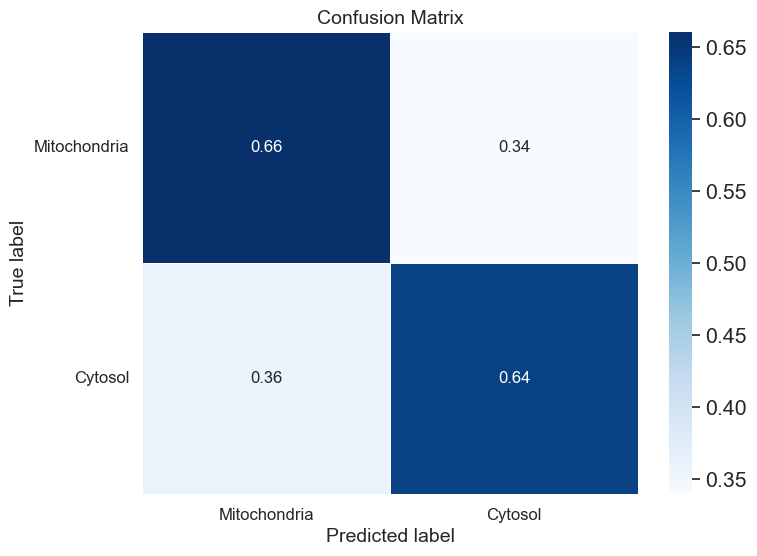

(0.656441717791411, 0.241618165870511, 0.7019487666034157)

In [79]:
test_accuracy, test_mcc, test_auc = ensemble(test_data, best_mito_models, best_cyto_models, alphabet, states)
test_accuracy, test_mcc, test_auc

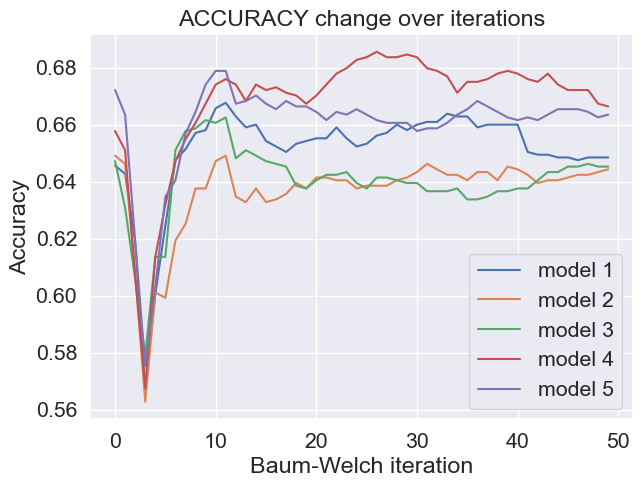

In [90]:
plt.figure(figsize=(7, 5))

for i in range(5):
    plt.plot(all_accuracies[i], label=f"model {i+1}")
    plt.xlabel("Baum-Welch iteration")
    plt.ylabel("Accuracy")
    plt.title("ACCURACY change over iterations")
plt.legend(loc="lower right")
plt.savefig(os.path.join(DATA_DIR, "model_accuracies_graph.png"), bbox_inches='tight', transparent=True)
plt.show()


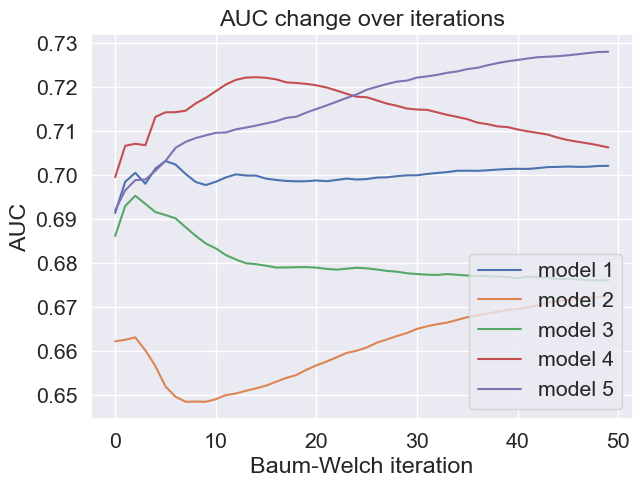

In [91]:
plt.figure(figsize=(7, 5))

for i in range(5):
    plt.plot(all_auc[i], label=f"model {i+1}")
    plt.xlabel("Baum-Welch iteration")
    plt.ylabel("AUC")
    plt.title("AUC change over iterations")
plt.legend(loc="lower right")
plt.savefig(os.path.join(DATA_DIR, "model_AUC_graph.png"), bbox_inches='tight', transparent=True)
plt.show()

### Viterbi

In [82]:
def initialize(input_encode, states, probability_matrix, emission_probability):

    delta = np.zeros(shape=(states, len(input_encode)))
    arrows = np.ndarray(shape=(states, len(input_encode)), dtype=object)

    # Initialize
    for i in range(0, states):
  
        delta[i][0] = probability_matrix[i] * emission_probability[i][input_encode[0]]
    
        arrows[i][0] = 0
    
    return delta, arrows

In [83]:
def viterbi(input_encode, states, delta, arrows, transition_matrix, emission_probability):

    for i in range(1, len(input_encode)):
        for j in range(0, states):

            max_arrow_probability = -np.inf
            max_arrow_proability_state = -1

            for k in range(0, states):

                # Iterate over each state "trasition" in position
                # 1=>1, 1=>2, 1=>3
                # 2=>1, 2=>2, 2=>3
                # 3=>1, 3=>2, 3=>3

                # i-1 = what position we are coming from
                # k = what state we are coming from
                # j = what state we are ending in
                arrow_probability = delta[k][i-1] * transition_matrix[k][j]

                # Check what transition from state k to j is the best (highest)
                if arrow_probability > max_arrow_probability:
                    max_arrow_probability = arrow_probability
                    max_arrow_proability_state = k

            # Store for state j in position i, which probability (transition) was best
            delta[j][i] = emission_probability[j][input_encode[i]] * max_arrow_probability

            # Store arrow
            arrows[j][i] = max_arrow_proability_state

    return delta, arrows

In [123]:
def backtrack(input_encode, arrows, previous_state, probability_path):

    for i in range(len(input_encode) - 2, -1, -1):
    
        current_state = arrows[previous_state][i+1]
        probability_path.append(str(current_state))

        previous_state = current_state
    
    return probability_path

In [143]:
def run_viterbi(peptides, probability_matrix, transition_matrix, emission_matrix):

    peptide_nr = 0

    all_input_encodes = []
    performance = []
    for peptide in peptides:

        peptide_nr += 1

        # Convert sequence from amino acids to numbers
        input_encode, peptide = encode(peptide, alphabet)
        all_input_encodes.append(input_encode)

        delta, arrows = initialize(input_encode, states, probability_matrix, emission_matrix)
        delta, arrows = viterbi(input_encode, states, delta, arrows, transition_matrix, emission_matrix)

        # Find the index of the max value in the last column of delta
        # Last column is the highest log‑probability of each state at the final time step
        max_state = np.argmax(delta[:, -1])
        max_value = delta[max_state, -1]    # What state has the highest log-probability 
        #print("log(Max_path):", max_value)

        probability_path = []
        probability_path.append(str(max_state))

        previous_state = max_state

        probability_path = backtrack(input_encode, arrows, previous_state, probability_path)

        # if probability_path[0] != '1':
        #     print("Sequence deviates from consensus: \t", peptide, "Backtrack:\t", probability_path)
        #     assert input_encode[0] != '1'

        performance.append((max_value, peptide))

    return performance

In [144]:
np.random.seed(1)

mito_test = [peptide for peptide, label in test_data if label == 1]
cyto_test = [peptide for peptide, label in test_data if label == 0]

mito_performance = []
cyto_performance = []
for i, (mito_model, cyto_model) in enumerate(zip(best_mito_models, best_cyto_models)):
    print("mito_model\n", mito_model[0])
    print("cyto_model\n", cyto_model[0])

    print(f"Mito viterbi model {i}")
    # print(mito_test)
    mito_performance.extend(run_viterbi(mito_test, 
                            probability_matrix=mito_model[0], 
                            transition_matrix=mito_model[1], 
                            emission_matrix=mito_model[2]))

    print(f"Cyto viterbi model {i}")
    # print(cyto_test)
    cyto_performance.extend(run_viterbi(cyto_test,
                            probability_matrix=cyto_model[0], 
                            transition_matrix=cyto_model[1], 
                            emission_matrix=cyto_model[2]))


mito_model
 [3.84858018e-05 9.98756151e-01 1.83843294e-04 1.02151965e-03]
cyto_model
 [5.12177573e-05 9.85633556e-01 2.53921160e-03 1.17760147e-02]
Mito viterbi model 0
Cyto viterbi model 0
mito_model
 [2.14670641e-56 1.00000000e+00 1.12270774e-88 1.68034155e-57]
cyto_model
 [2.67708142e-60 1.00000000e+00 1.69772606e-83 2.07387016e-57]
Mito viterbi model 1
Cyto viterbi model 1
mito_model
 [0.01808927 0.57913901 0.1330569  0.26971482]
cyto_model
 [0.0215132  0.39989142 0.16192443 0.41667095]
Mito viterbi model 2
Cyto viterbi model 2
mito_model
 [8.88839560e-17 1.00000000e+00 3.46172831e-22 5.07232471e-16]
cyto_model
 [1.23794728e-17 1.00000000e+00 1.46443825e-19 1.13787286e-14]
Mito viterbi model 3
Cyto viterbi model 3
mito_model
 [3.04276148e-52 1.00000000e+00 1.21665609e-89 2.18668249e-57]
cyto_model
 [1.67056198e-60 1.00000000e+00 5.45671450e-84 6.35026116e-57]
Mito viterbi model 4
Cyto viterbi model 4


In [134]:
mito_performance.sort(reverse=True)
mito_performance

[(np.float64(2.569802556584238e-05), 'NAN'),
 (np.float64(2.493346487717528e-05), 'NAN'),
 (np.float64(1.2913616913410713e-05), 'NAN'),
 (np.float64(1.1805204148687285e-05), 'NAN'),
 (np.float64(1.107204005593248e-05), 'NAN'),
 (np.float64(1.0825670480418478e-48),
  'MKPGPPHRAGAAHGAGAGAGAAAGPGARGLLLPPLLLLLLAGRAAGAQRW'),
 (np.float64(9.524509799467263e-49),
  'MKPGPPHRAGAAHGAGAGAGAAAGPGARGLLLPPLLLLLLAGRAAGAQRW'),
 (np.float64(4.201543844884599e-49),
  'MKPGPPHRAGAAHGAGAGAGAAAGPGARGLLLPPLLLLLLAGRAAGAQRW'),
 (np.float64(4.369028640720853e-50),
  'MGARASGGPLARAGLLLLLLLLLLLGLLAPGAQGARGRGGAEKNSYRRTV'),
 (np.float64(3.3740051064882525e-50),
  'MGARASGGPLARAGLLLLLLLLLLLGLLAPGAQGARGRGGAEKNSYRRTV'),
 (np.float64(2.7690688088160968e-50),
  'MGARASGGPLARAGLLLLLLLLLLLGLLAPGAQGARGRGGAEKNSYRRTV'),
 (np.float64(1.1531709381595751e-50),
  'MGAAGSSALARFVLLAQSRPGWLGVAALGLTAVALGAVAWRRAWPTRRRR'),
 (np.float64(7.539952755345528e-51),
  'MGAAGSSALARFVLLAQSRPGWLGVAALGLTAVALGAVAWRRAWPTRRRR'),
 (np.float64(5.97

In [ ]:
cyto_performance.sort(reverse=True)
cyto_performance